## Блок 1

Заданий 1

файл Вариант 15.csv находится в корне проекта

Задание 2

Одно из значений вероятности закона распределения не указано. Чтобы найти его, воспользуемся тем, что сумма всех вероятностей должна быть равна 1.

То есть неизвестная вероятность равна:

$$p = 1 - \sum p_i$$

In [18]:
import pandas as pd

df: pd.DataFrame = pd.read_csv("Вариант 15.csv")
P = df.set_index("XY")
missing = 1 - P.sum().sum()
print(missing)


0.027900000000000036


Задание 3

Многомерная функция распределения находится как сумма всех вероятностей, расположенных в таблице левее и выше выбранной ячейки, включая саму ячейку:

$$F(x, y) = P(X \le x, Y \le y) = \sum_{X_i \le x,\; Y_j \le y} p_{ij}$$

In [ ]:
P = df.set_index("XY")
P.columns = P.columns.astype(int)
P.index = P.index.astype(int)
missing = 1 - P.sum().sum()
P = P.sort_index().sort_index(axis=1).fillna(missing)

F = P.cumsum(axis=0).cumsum(axis=1)

print("F(x, y) = P(X <= x, Y <= y):")

for y in F.index:
    for x in F.columns:
        print(f"P(X <= {x}, Y <= {y}) = {F.loc[y, x]:.4f}")

F(x, y) = P(X <= x, Y <= y):
P(X <= -92, Y <= -57) = 0.0131
P(X <= -74, Y <= -57) = 0.0326
P(X <= -23, Y <= -57) = 0.0459
P(X <= -11, Y <= -57) = 0.0469
P(X <= 24, Y <= -57) = 0.0643
P(X <= 58, Y <= -57) = 0.0669
P(X <= 63, Y <= -57) = 0.0792
P(X <= 67, Y <= -57) = 0.0815
P(X <= 84, Y <= -57) = 0.0831
P(X <= 87, Y <= -57) = 0.0990
P(X <= -92, Y <= -55) = 0.0257
P(X <= -74, Y <= -55) = 0.0458
P(X <= -23, Y <= -55) = 0.0674
P(X <= -11, Y <= -55) = 0.0809
P(X <= 24, Y <= -55) = 0.1050
P(X <= 58, Y <= -55) = 0.1284
P(X <= 63, Y <= -55) = 0.1797
P(X <= 67, Y <= -55) = 0.2133
P(X <= 84, Y <= -55) = 0.2163
P(X <= 87, Y <= -55) = 0.2349
P(X <= -92, Y <= -50) = 0.0424
P(X <= -74, Y <= -50) = 0.0832
P(X <= -23, Y <= -50) = 0.1099
P(X <= -11, Y <= -50) = 0.1525
P(X <= 24, Y <= -50) = 0.1835
P(X <= 58, Y <= -50) = 0.2087
P(X <= 63, Y <= -50) = 0.2681
P(X <= 67, Y <= -50) = 0.3514
P(X <= 84, Y <= -50) = 0.3629
P(X <= 87, Y <= -50) = 0.3887
P(X <= -92, Y <= -38) = 0.0520
P(X <= -74, Y <= -38) = 0.09

Задание 4

Маргинальный закон распределения для X получается суммированием совместных вероятностей по всем значениям Y:

$$P(X = x_i) = \sum_j p_{ij}$$

Маргинальный закон распределения для Y получается суммированием совместных вероятностей по всем значениям X:

$$P(Y = y_j) = \sum_i p_{ij}$$

Функции маргинальных распределений строятся как накопленные суммы соответствующих маргинальных вероятностей:

$$F_X(x) = P(X \le x), \quad F_Y(y) = P(Y \le y)$$

x,P(X = x),F_X(x)
-11,0.092600,0.092600
-23,0.111400,0.204000
-74,0.092500,0.296500
-92,0.121800,0.418300
24,0.090900,0.509200
58,0.085100,0.594300
63,0.139700,0.734000
67,0.117300,0.851300
84,0.054400,0.905700
87,0.094300,1.000000


y,P(Y = y),F_Y(y)
-57,0.099000,0.099000
-55,0.135900,0.234900
-50,0.153800,0.388700
-38,0.085400,0.474100
-36,0.088600,0.562700
-26,0.089600,0.652300
-10,0.112900,0.765200
27,0.093100,0.858300
76,0.050100,0.908400
99,0.091600,1.000000


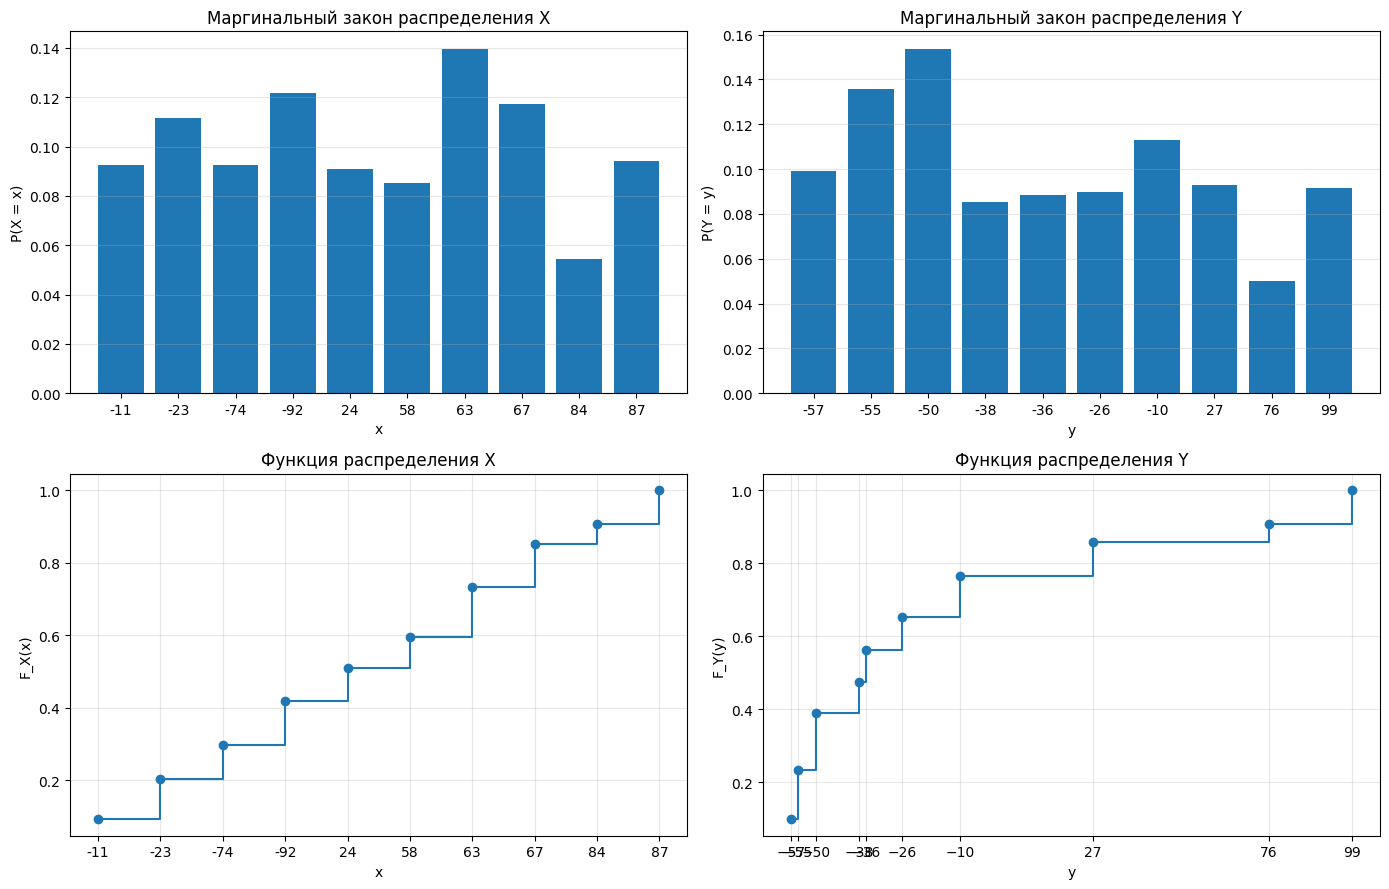

In [ ]:
import matplotlib.pyplot as plt

df = pd.read_csv("Вариант 15.csv")
P = df.set_index("XY")
P.columns = P.columns.astype(int)
P.index = P.index.astype(int)
missing = 1 - P.sum().sum()
P = P.sort_index().sort_index(axis=1).fillna(missing)

marginal_x = P.sum(axis=0)
marginal_y = P.sum(axis=1)

F_x = marginal_x.cumsum()
F_y = marginal_y.cumsum()

distribution_x = pd.DataFrame({
    "x": marginal_x.index,
    "P(X = x)": marginal_x.values,
    "F_X(x)": F_x.values,
})

distribution_y = pd.DataFrame({
    "y": marginal_y.index,
    "P(Y = y)": marginal_y.values,
    "F_Y(y)": F_y.values,
})

display(distribution_x.style.hide(axis="index"))
display(distribution_y.style.hide(axis="index"))

fig, axes = plt.subplots(2, 2, figsize=(14, 9))

axes[0, 0].bar(marginal_x.index.astype(str), marginal_x.values)
axes[0, 0].set_title("Маргинальный закон распределения X")
axes[0, 0].set_xlabel("x")
axes[0, 0].set_ylabel("P(X = x)")
axes[0, 0].grid(axis="y", alpha=0.3)

axes[0, 1].bar(marginal_y.index.astype(str), marginal_y.values)
axes[0, 1].set_title("Маргинальный закон распределения Y")
axes[0, 1].set_xlabel("y")
axes[0, 1].set_ylabel("P(Y = y)")
axes[0, 1].grid(axis="y", alpha=0.3)

axes[1, 0].step(marginal_x.index, F_x.values, where="post", marker="o")
axes[1, 0].set_title("Функция распределения X")
axes[1, 0].set_xlabel("x")
axes[1, 0].set_ylabel("F_X(x)")
axes[1, 0].set_xticks(marginal_x.index)
axes[1, 0].grid(alpha=0.3)

axes[1, 1].step(marginal_y.index, F_y.values, where="post", marker="o")
axes[1, 1].set_title("Функция распределения Y")
axes[1, 1].set_xlabel("y")
axes[1, 1].set_ylabel("F_Y(y)")
axes[1, 1].set_xticks(marginal_y.index)
axes[1, 1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

Задание 5

Для маргинальных распределений числовые характеристики находятся по формулам:

$$E(X) = \sum x_i p_i$$

$$D(X) = \sum (x_i - E(X))^2 p_i$$

$$\sigma(X) = \sqrt{D(X)}$$

Медиана для дискретного распределения — это первое значение, при котором функция распределения становится не меньше 0.5. Мода — значение случайной величины с наибольшей вероятностью.

In [56]:
def get_characteristics(name, probabilities):
    values = pd.to_numeric(probabilities.index.to_series())
    expected_value = (values * probabilities).sum()
    variance = ((values - expected_value) ** 2 * probabilities).sum()
    standard_deviation = variance ** 0.5
    median = probabilities.cumsum()[probabilities.cumsum() >= 0.5].index[0]
    max_probability = probabilities.max()
    modes = probabilities[probabilities == max_probability].index.tolist()

    return {
        "Величина": name,
        "Математическое ожидание": expected_value,
        "Дисперсия": variance,
        "Среднее квадратичное отклонение": standard_deviation,
        "Медиана": median,
        "Мода": ", ".join(map(str, modes)),
    }

characteristics = pd.DataFrame([
    get_characteristics("X", marginal_x),
    get_characteristics("Y", marginal_y),
])

display(
    characteristics.style.hide(axis="index")
)

Величина,Математическое ожидание,Дисперсия,Среднее квадратичное отклонение,Медиана,Мода
X,14.919900,3902.243884,62.467943,24,63
Y,-15.311200,2447.837555,49.475626,-36,-50


Задание 6

Случайные величины X и Y независимы, если для любых значений x и y выполняется равенство:

$$P(X = x, Y = y) = P(X = x) \cdot P(Y = y)$$

Проверим это равенство для всех пар значений.

In [45]:
independent_probabilities = pd.DataFrame(index=P.index, columns=P.columns, dtype=float)

for y in P.index:
    for x in P.columns:
        independent_probabilities.loc[y, x] = marginal_y.loc[y] * marginal_x.loc[x]

difference = P - independent_probabilities
max_difference = difference.abs().max().max()

if max_difference < 1e-10:
    print("Случайные величины X и Y независимы.")
else:
    print("Случайные величины X и Y зависимы.")
    print(f"Максимальное расхождение: {max_difference:.4f}")

    for y in P.index:
        for x in P.columns:
            if abs(difference.loc[y, x]) >= 1e-10:
                print(f"Например, для X = {x}, Y = {y}:")
                print(f"P(X = {x}, Y = {y}) = {P.loc[y, x]:.4f}")
                print(f"P(X = {x}) * P(Y = {y}) = {independent_probabilities.loc[y, x]:.4f}")
                break
        else:
            continue
        break

Случайные величины X и Y зависимы.
Максимальное расхождение: 0.0317
Например, для X = -11, Y = -57:
P(X = -11, Y = -57) = 0.0010
P(X = -11) * P(Y = -57) = 0.0092


Задание 7

Коэффициент линейной корреляции находится по формуле:

$$r_{XY} = \frac{cov(X, Y)}{\sigma_X \sigma_Y}$$

Ковариация находится по формуле:

$$cov(X, Y) = E(XY) - E(X)E(Y)$$

In [53]:
expected_x = (marginal_x.index.to_series() * marginal_x).sum()
expected_y = (marginal_y.index.to_series() * marginal_y).sum()

variance_x = ((marginal_x.index.to_series() - expected_x) ** 2 * marginal_x).sum()
variance_y = ((marginal_y.index.to_series() - expected_y) ** 2 * marginal_y).sum()

std_x = variance_x ** 0.5
std_y = variance_y ** 0.5

expected_xy = 0

for y in P.index:
    for x in P.columns:
        expected_xy += x * y * P.loc[y, x]

covariance = expected_xy - expected_x * expected_y
correlation = covariance / (std_x * std_y)

print(f"E(X) = {expected_x:.4f}")
print(f"E(Y) = {expected_y:.4f}")
print(f"E(XY) = {expected_xy:.4f}")
print(f"cov(X, Y) = {covariance:.4f}")
print(f"r = {correlation:.4f}")

if abs(correlation) < 1e-10:
    print("Коэффициент корреляции равен нулю. Линейная связь отсутствует.")
else:
    print("Коэффициент корреляции не равен нулю.")

if abs(correlation) < 0.1:
    print("Так как значение близко к нулю, линейная связь между X и Y очень слабая.")
elif correlation > 0:
    print("Связь положительная: при увеличении X значение Y в среднем также склонно увеличиваться.")
else:
    print("Связь отрицательная: при увеличении X значение Y в среднем склонно уменьшаться.")

E(X) = 14.9199
E(Y) = -15.3112
E(XY) = -90.9635
cov(X, Y) = 137.4781
r = 0.0445
Коэффициент корреляции не равен нулю.
Так как значение близко к нулю, линейная связь между X и Y очень слабая.


Задание 8

Уравнение регрессии Y на X это:

$$E(Y \mid X = x)$$

Для дискретного распределения оно находится по формуле:

$$E(Y \mid X = x_i) = \sum_j y_j \cdot P(Y = y_j \mid X = x_i)$$

Так как

$$P(Y = y_j \mid X = x_i) = \frac{P(X = x_i, Y = y_j)}{P(X = x_i)},$$

то итоговая формула имеет вид:

$$E(Y \mid X = x_i) = \frac{\sum_j y_j p_{ij}}{P(X = x_i)}$$

In [57]:
regression_y_on_x = []

for x in P.columns:
    conditional_expected_y = 0

    for y in P.index:
        conditional_expected_y += y * P.loc[y, x] / marginal_x.loc[x]

    regression_y_on_x.append({
        "x": x,
        "E(Y | X = x)": conditional_expected_y,
    })

regression_table = pd.DataFrame(regression_y_on_x)

display(
    regression_table.style.hide(axis="index")
)

x,E(Y | X = x)
-92,-23.896552
-74,-12.962162
-23,-21.402154
-11,-5.832613
24,-6.475248
58,-14.017626
63,-22.060129
67,-26.455243
84,-25.610294
87,11.478261
